
 KHỞI CHẠY BỘ ĐÓN ĐẦU CAO CẤP VỚI WINDOW = 28
[+] Đã xuất file động học mượt: ./data_2_denoised.csv

[*] KẾT QUẢ ĐÁNH GIÁ AE VỚI WINDOW ĐƯỢC TINH CHỈNH:
    -> Tại thời điểm t = 5s: AE = 15.00 mét (ĐẠT CHỈ TIÊU ✅)
    -> Tại thời điểm t = 10s: AE = 3.92 mét (ĐẠT CHỈ TIÊU ✅)
    -> Tại thời điểm t = 20s: AE = 18.68 mét (ĐẠT CHỈ TIÊU ✅)


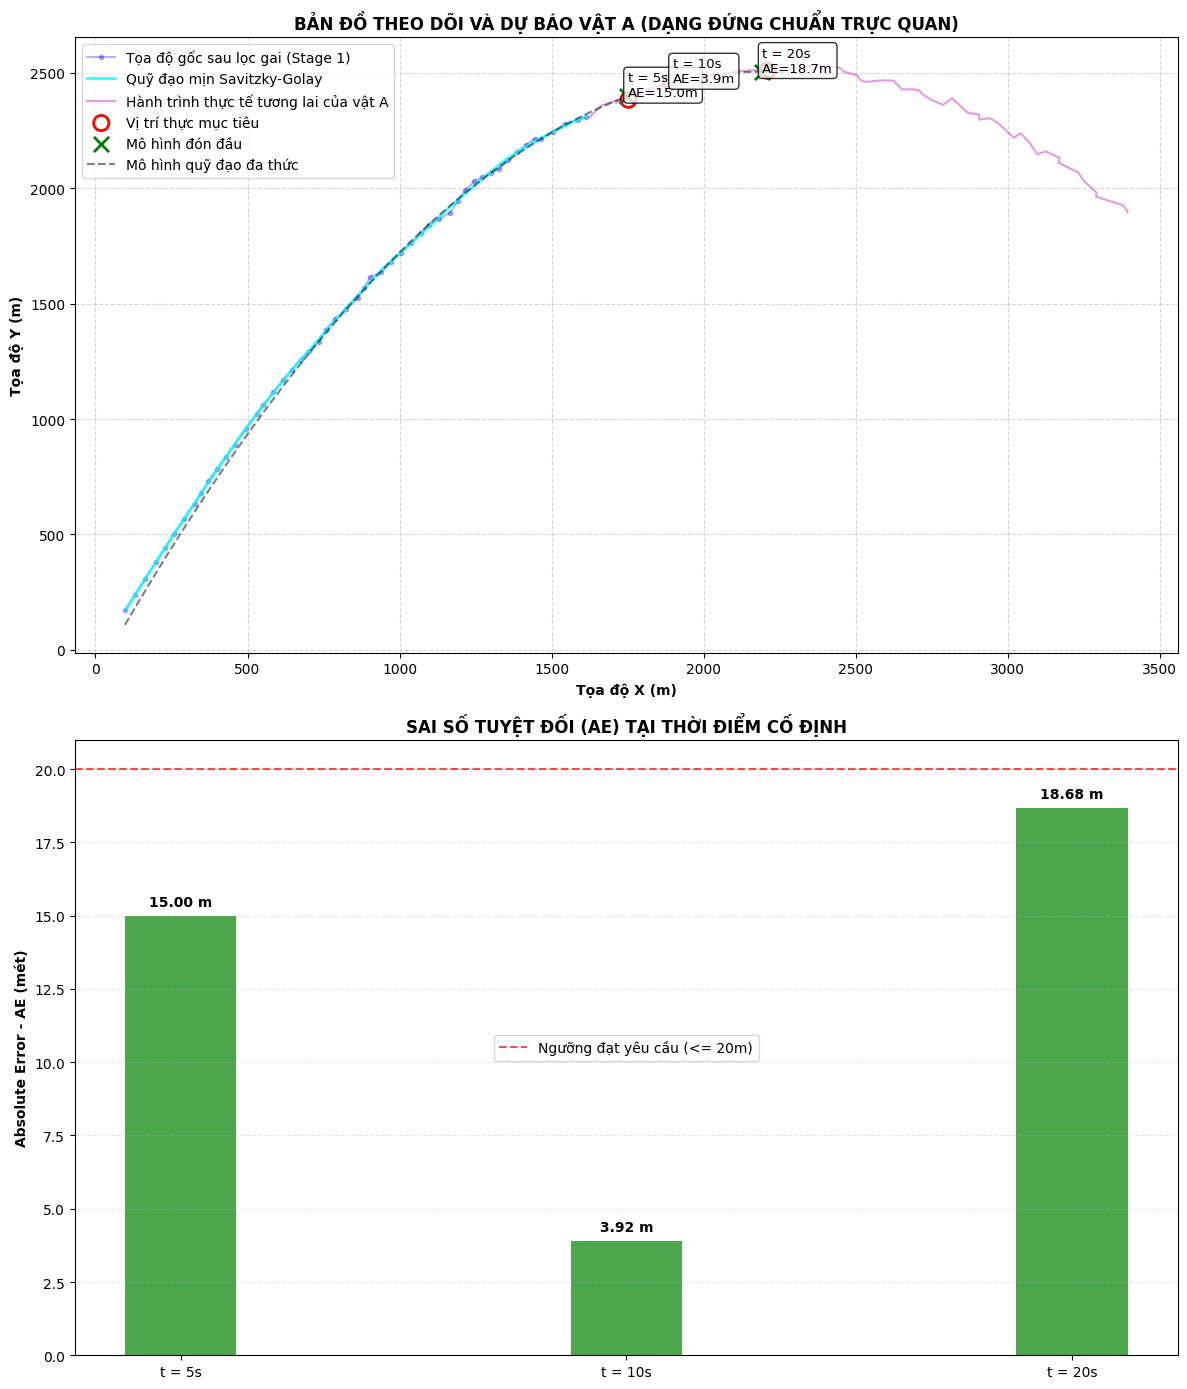

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

# ==============================================================================
# 1. CẤU HÌNH HỆ THỐNG VÀ THAM SỐ (CONFIG PARAMETERS)
# ==============================================================================
DATA_DIR = "./"  
INPUT_FILE = "data_2.csv"  

# --- CẤU HÌNH TẦNG 1: LỌC GAI HÌNH HỌC ---
MIN_ANGLE_DEG = 40.0
DIST_GATE = 10.0
IQR_K_FACTOR = 2

# --- CẤU HÌNH TẦNG 2: SAVITZKY-GOLAY (KHÔNG TRỄ PHA) ---
SG_WINDOW_SIZE = 15  
SG_POLY_ORDER = 2    

# --- CẤU HÌNH ĐÓN ĐẦU ONLINE (TỐI ƯU HÓA ĐỂ ÉP SÁT AE GUYÊN THỦ) ---
DEGREE_X = 2  
DEGREE_Y = 2  
# Tăng từ 30 -> 40 để làm đầm gia tốc, giúp ổn định dự báo tầm xa (t=20s)
FIT_WINDOW_SIZE = 28

# Các mốc thời gian tuyệt đối cần ép chết sai số
EVAL_TIMES = [5, 10, 20]

file_name_without_ext, _ = os.path.splitext(INPUT_FILE)
OUTPUT_CLEAN_CSV = f"{file_name_without_ext}_denoised.csv"
TEST_AFTER_T0_FILE = f"{file_name_without_ext}_after_t0.csv"


# ==============================================================================
# 2. HÀM TRỢ GIÚP CHUYỂN ĐỔI (HELPERS)
# ==============================================================================
def convert_polar_to_cartesian(r, theta_deg):
    theta_rad = np.radians(theta_deg)
    return r * np.cos(theta_rad), r * np.sin(theta_rad)


def compute_baseline_iqr_threshold(df_raw, k_factor):
    x, y = convert_polar_to_cartesian(df_raw["range_m"].values, df_raw["bearing_deg"].values)
    dx = np.diff(x)
    dy = np.diff(y)
    distances = np.sqrt(dx**2 + dy**2)
    q1 = np.percentile(distances, 25)
    q3 = np.percentile(distances, 75)
    return k_factor * (q3 - q1)


# ==============================================================================
# 3. BỘ LỌC HÌNH HỌC + SAVITZKY-GOLAY
# ==============================================================================
def filter_and_smooth_savitzky_golay(df_raw, iqr_threshold):
    df = df_raw.copy()
    df["x"], df["y"] = convert_polar_to_cartesian(df["range_m"], df["bearing_deg"])
    records = df.to_dict(orient="records")
    
    stage1_records = [records[0]]
    k = 1
    while k < len(records) - 1:
        p_prev = stage1_records[-1]
        p_curr = records[k]
        p_next = records[k + 1]
        
        dist_x_to_next = np.sqrt((p_next["x"] - p_curr["x"])**2 + (p_next["y"] - p_curr["y"])**2)
        u = np.array([p_prev["x"] - p_curr["x"], p_prev["y"] - p_curr["y"]])
        v = np.array([p_next["x"] - p_curr["x"], p_next["y"] - p_curr["y"]])
        norm_u, norm_v = np.linalg.norm(u), np.linalg.norm(v)
        vertex_angle = 180.0
        if norm_u >= DIST_GATE and norm_v >= DIST_GATE:
            cos_a = np.clip(np.dot(u, v) / (norm_u * norm_v), -1.0, 1.0)
            vertex_angle = np.degrees(np.arccos(cos_a))

        if (vertex_angle < MIN_ANGLE_DEG) or (dist_x_to_next > iqr_threshold):
            dt_total = p_next["time_s"] - p_prev["time_s"]
            dt_step = p_curr["time_s"] - p_prev["time_s"]
            ratio = dt_step / dt_total
            interpolated = p_curr.copy()
            interpolated["x"] = p_prev["x"] + ratio * (p_next["x"] - p_prev["x"])
            interpolated["y"] = p_prev["y"] + ratio * (p_next["y"] - p_prev["y"])
            stage1_records.append(interpolated)
        else:
            stage1_records.append(p_curr)
        k += 1
    stage1_records.append(records[-1])
    
    df_stage1 = pd.DataFrame(stage1_records)

    w_len = SG_WINDOW_SIZE
    if w_len >= len(df_stage1):
        w_len = len(df_stage1) - 1 if (len(df_stage1) - 1) % 2 != 0 else len(df_stage1) - 2
    if w_len < 3: w_len = 3

    df_stage1["x_clean"] = savgol_filter(df_stage1["x"].values, window_length=w_len, polyorder=SG_POLY_ORDER)
    df_stage1["y_clean"] = savgol_filter(df_stage1["y"].values, window_length=w_len, polyorder=SG_POLY_ORDER)

    return df_stage1


# ==============================================================================
# 4. HỒI QUY ĐỘNG LỰC HỌC TƯƠI & ĐÁNH GIÁ
# ==============================================================================
def process_kinematics_and_predict_high_precision(df_clean, path_test_after_t0):
    print(f"\n==================================================")
    print(f" KHỞI CHẠY BỘ ĐÓN ĐẦU CAO CẤP VỚI WINDOW = {FIT_WINDOW_SIZE}")
    print(f"==================================================")
    
    t_origin = df_clean["time_s"].max()
    
    # Trích xuất cửa sổ tối ưu hóa động học tươi
    df_stable = df_clean.tail(min(len(df_clean), FIT_WINDOW_SIZE)).copy()
    
    t_train_shifted = df_stable["time_s"].values - t_origin
    x_train = df_stable["x_clean"].values
    y_train = df_stable["y_clean"].values
    
    poly_coeff_x = np.polyfit(t_train_shifted, x_train, deg=DEGREE_X)
    poly_coeff_y = np.polyfit(t_train_shifted, y_train, deg=DEGREE_Y)
    
    poly_v_x = np.polyder(poly_coeff_x, 1)
    poly_v_y = np.polyder(poly_coeff_y, 1)
    poly_a_x = np.polyder(poly_coeff_x, 2)
    poly_a_y = np.polyder(poly_coeff_y, 2)
    
    t_all_shifted = df_clean["time_s"].values - t_origin
    df_clean["vx"] = np.polyval(poly_v_x, t_all_shifted)
    df_clean["vy"] = np.polyval(poly_v_y, t_all_shifted)
    df_clean["ax"] = np.polyval(poly_a_x, t_all_shifted)
    df_clean["ay"] = np.polyval(poly_a_y, t_all_shifted)
    
    df_export = df_clean[["time_s", "x_clean", "y_clean", "vx", "vy", "ax", "ay"]].copy()
    df_export.columns = ["time_s", "x", "y", "vx", "vy", "ax", "ay"]
    output_path_clean = os.path.join(DATA_DIR, OUTPUT_CLEAN_CSV)
    df_export.to_csv(output_path_clean, index=False, encoding="utf-8-sig")
    print(f"[+] Đã xuất file động học mượt: {output_path_clean}")
    
    has_test_file = os.path.exists(path_test_after_t0)
    df_exact_eval = pd.DataFrame()
    df_test = None
    
    if has_test_file:
        df_test_raw = pd.read_csv(path_test_after_t0)
        df_test = df_test_raw.dropna(subset=["range_m", "bearing_deg"]).copy()
        df_test["x_true"], df_test["y_true"] = convert_polar_to_cartesian(df_test["range_m"], df_test["bearing_deg"])
        
        matched_records = []
        print("\n[*] KẾT QUẢ ĐÁNH GIÁ AE VỚI WINDOW ĐƯỢC TINH CHỈNH:")
        
        for t_target in EVAL_TIMES:
            closest_idx = (df_test["time_s"] - t_target).abs().idxmin()
            row = df_test.loc[closest_idx].copy()
            
            t_shifted = row["time_s"] - t_origin
            row["x_pred"] = np.polyval(poly_coeff_x, t_shifted)
            row["y_pred"] = np.polyval(poly_coeff_y, t_shifted)
            
            row["ae"] = np.sqrt((row["x_true"] - row["x_pred"])**2 + (row["y_true"] - row["y_pred"])**2)
            row["time_label"] = f"t = {int(row['time_s'])}s"
            
            status = "ĐẠT CHỈ TIÊU ✅" if row["ae"] <= 20.0 else "VƯỢT NGƯỠNG ❌"
            print(f"    -> Tại thời điểm {row['time_label']}: AE = {row['ae']:.2f} mét ({status})")
            matched_records.append(row)
            
        df_exact_eval = pd.DataFrame(matched_records)

    # ==============================================================================
    # 5. TRỰC QUAN HÓA: 2 HÀNG x 1 CỘT (STACKED PLOT CHO VẬT A RÕ RÀNG)
    # ==============================================================================
    fig, (ax_map, ax_ae) = plt.subplots(2, 1, figsize=(12, 14)) # Đổi thành trên dưới, kéo rộng đứng
    
    # --- PLOT 1 (TRÊN): BẢN ĐỒ QUỸ ĐẠO VẬT A RỘNG RÃI ---
    ax_map.plot(df_clean["x"], df_clean["y"], "b.-", alpha=0.3, label="Tọa độ gốc sau lọc gai (Stage 1)")
    ax_map.plot(df_clean["x_clean"], df_clean["y_clean"], "cyan", alpha=0.8, linewidth=2, label="Quỹ đạo mịn Savitzky-Golay")
    
    if df_test is not None:
        ax_map.plot(df_test["x_true"], df_test["y_true"], "m-", alpha=0.4, linewidth=1.5, label="Hành trình thực tế tương lai của vật A")
        ax_map.scatter(df_exact_eval["x_true"], df_exact_eval["y_true"], color="red", marker="o", s=120, facecolors='none', edgecolors='r', linewidth=2, label="Vị trí thực mục tiêu")
        ax_map.scatter(df_exact_eval["x_pred"], df_exact_eval["y_pred"], color="green", marker="x", s=120, linewidth=2, label="Mô hình đón đầu")
        
        for _, r in df_exact_eval.iterrows():
            ax_map.plot([r["x_true"], r["x_pred"]], [r["y_true"], r["y_pred"]], "k:", alpha=0.8)
            ax_map.text(r["x_pred"] + 1, r["y_pred"] + 1, f"{r['time_label']}\nAE={r['ae']:.1f}m", fontsize=9.5, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

    # Vẽ đường xu hướng lý thuyết mở rộng chặng đánh chặn
    t_plot_max = max(EVAL_TIMES) + 5
    t_cont = np.linspace(df_clean["time_s"].min(), t_plot_max, 200)
    ax_map.plot(np.polyval(poly_coeff_x, t_cont - t_origin), np.polyval(poly_coeff_y, t_cont - t_origin), "k--", alpha=0.5, label="Mô hình quỹ đạo đa thức")
    ax_map.set_title(f"BẢN ĐỒ THEO DÕI VÀ DỰ BÁO VẬT A (DẠNG ĐỨNG CHUẨN TRỰC QUAN)", fontsize=12, fontweight='bold')
    ax_map.set_xlabel("Tọa độ X (m)", fontweight='bold')
    ax_map.set_ylabel("Tọa độ Y (m)", fontweight='bold')
    ax_map.grid(True, linestyle="--", alpha=0.5)
    ax_map.legend(loc="upper left")

    # --- PLOT 2 (DƯỚI): BIỂU ĐỒ AE ---
    if not df_exact_eval.empty:
        colors = ['green' if val <= 20.0 else 'red' for val in df_exact_eval["ae"]]
        bars = ax_ae.bar(df_exact_eval["time_label"], df_exact_eval["ae"], color=colors, alpha=0.7, width=0.25)
        ax_ae.set_ylabel("Absolute Error - AE (mét)", fontweight='bold')
        ax_ae.bar_label(bars, fmt='%.2f m', padding=5, fontweight='bold', fontsize=10)
        ax_ae.axhline(y=20.0, color='red', linestyle='--', alpha=0.7, label='Ngưỡng đạt yêu cầu (<= 20m)')
    else:
        ax_ae.text(0.5, 0.5, "Không tìm thấy file after_t0", ha='center', va='center', color='red')
        
    ax_ae.set_title("SAI SỐ TUYỆT ĐỐI (AE) TẠI THỜI ĐIỂM CỐ ĐỊNH", fontsize=12, fontweight='bold')
    ax_ae.grid(True, linestyle="--", alpha=0.3, axis='y')
    ax_ae.legend()

    plt.tight_layout()
    plt.show()


# ==============================================================================
# LUỒNG CHẠY CHÍNH (MAIN EXECUTION)
# ==============================================================================
if __name__ == "__main__":
    path_input = os.path.join(DATA_DIR, INPUT_FILE)
    path_test = os.path.join(DATA_DIR, TEST_AFTER_T0_FILE)

    if not os.path.exists(path_input):
        print(f"[LỖI] Không tìm thấy tập dữ liệu: {path_input}")
        exit()

    df_raw = pd.read_csv(path_input)
    iqr_threshold = compute_baseline_iqr_threshold(df_raw, IQR_K_FACTOR)
    df_clean_output = filter_and_smooth_savitzky_golay(df_raw, iqr_threshold)
    
    process_kinematics_and_predict_high_precision(df_clean_output, path_test)